<a href="https://colab.research.google.com/github/Williams-MP/VIU_Misc/blob/main/07MIAR_Grupo9E_Proyecto_Programacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07MIAR - Redes Neuronales y Deep Learning: Proyecto de programación "*Deep Vision in classification tasks*"


## Enunciado

En esta actividad, el alumno debe **evaluar y comparar dos estrategias** para la **clasificación de imágenes** empleando el **dataset asignado**. Los alumnos deberá resolver el reto proponiendo una solución válida **basada en aprendizaje profundo**, más concretamente en redes neuronales convolucionales (**CNNs**). Será indispensable que la solución propuesta siga el **pipeline visto en clase** para resolver este tipo de tareas de inteligencia artificial:

1.   **Carga** del conjunto de datos
2.   **Inspección** del conjunto de datos
3.   **Acondicionamiento** del conjunto de datos
4.   Desarrollo de la **arquitectura** de red neuronal y **entrenamiento** de la solución
5.   **Monitorización** del proceso de **entrenamiento** para la toma de decisiones
6.   **Evaluación** del modelo predictivo y planteamiento de la siguiente prueba experimental

### Estrategia 1: Entrenar desde cero o *from scratch*

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

### Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

## Normas a seguir

- Será **indispensable** realizar el **trabajo por parejas**. Dichas parejas de alumnxs se generarán **de manera automática** teniendo en cuenta el pais de residencia con el objetivo de facilitar el trabajo en equipo.  
- Se debe entregar un **ÚNICO FICHERO PDF POR ALUMNO** que incluya las instrucciones presentes en el Colab Noteboook y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso llevado a cabo en cada estrategia (i.e. carga de datos, inspección de datos, acondicionamiento, proceso de entrenamiento y proceso de validación del modelo).
- **La memoria del trabajo** (el fichero PDF mencionado en el punto anterior) deberá **subirla cada integrante del grupo** (aunque se trate de un documento idéntico) a la actividad que se habilitará **en CampusVIU**.
- Se recomienda trabajar respecto a un directorio base (**BASE_FOLDER**) para facilitar el trabajo en equipo. En este notebook se incluye un ejemplo de cómo almacenar/cargar datos utilizando un directorio base.
- Las **redes propuestas** deben estar **entrenadas** (y **EVIDENCIAR este proceso en el documento PDF**). La entrega de una **red sin entrenar** supondrá **perdida de puntos**.
- Si se desea **evidenciar alguna métrica** del proceso de entrenamiento (precisión, pérdida, etc.), estas deben ser generadas.
- Todos los **gráficos** que se deseen mostrar deberán **generarse en el Colab Notebook** para que tras la conversión aparezcan en el documento PDF.

## *Tips* para realizar la actividad con éxito
- Los **datos** se cargarán directamente **desde** la plataforma **Kaggle** mediante su API (https://github.com/Kaggle/kaggle-api). En este Notebook se incluye un ejemplo de como hacerlo. Se recomienda generar una función que aborde esta tarea.
- El **documento PDF a entregar** como solución de la actividad se debe **generar automáticamente desde el fichero ".ipynb"**. En este Notebook se incluye un ejemplo de como hacerlo.
- **Generar secciones y subsecciones en el Colab Notebook** supondrá que el documento **PDF generado** queda totalmente **ordenado** facilitando la evaluación al docente.
- Se recomienda encarecidamente **incluir comentarios concisos pero aclaratorios**.
- Es muy recomendable crear una **última sección** de texto en el Colab Notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterios de evaluación

- **Seguimiento** de las **normas establecidas** en la actividad (detalladas anteriormente).
- Creación de una **solución que resuelva la tarea de clasificación**, i.e. que las figuras de mérito empleadas para medir la bondad del modelo predictivo evidencien un *performance* superior al rendimiento estocástico.
- **Claridad** en la creación de la solución, en las justificaciones sobre la toma de decisiones llevada a cabo así como en las comparativas y conclusiones finales.
- **Efectividad** al presentar las comparaciones entre métricas de evaluación de ambas estrategias.
- **Demostración** de la utilización de **técnicas de regularización** para mejorar el rendimiento de los modelos.

## Ejemplo de carga de datos desde la plataforma Kaggle

In [ ]:
# En primer lugar se debe generar un API de Kaggle personal, para ello:
#  1. Registrarse en  https://www.kaggle.com
#  2. Ir a 'Account tab' de tu perfil y seleccionar 'Create API Token'
#  3. Almacenar en tu ordenador local el fichero kaggle.json

In [ ]:
!pip uninstall -y kaggle kagglesdk
# Nos aseguramos que tenemos instalada la última versión de la API de Kaggle en Colab
# !pip install --upgrade --force-reinstall --no-deps kaggle

Found existing installation: kaggle 2.2.1
Uninstalling kaggle-2.2.1:
  Successfully uninstalled kaggle-2.2.1
Found existing installation: kagglesdk 0.1.28
Uninstalling kagglesdk-0.1.28:
  Successfully uninstalled kagglesdk-0.1.28


In [ ]:
!pip install git+https://github.com/Kaggle/kaggle-api.git --upgrade

  Cloning https://github.com/Kaggle/kaggle-api.git to /tmp/pip-req-build-36_mhm01
  Running command git clone --filter=blob:none --quiet https://github.com/Kaggle/kaggle-api.git /tmp/pip-req-build-36_mhm01
  Resolved https://github.com/Kaggle/kaggle-api.git to commit af23c92f65ae90a94d9889171b7c0c7c0fe4debc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached kagglesdk-0.1.28-py3-none-any.whl.metadata (13 kB)
Using cached kagglesdk-0.1.28-py3-none-any.whl (230 kB)
  Created wheel for kaggle: filename=kaggle-2.2.1-py3-none-any.whl size=134548 sha256=2d77b59fe502927a1557aa51a7a7f3eb442d3edcbdbef034225986cfae6a6e2a
  Stored in directory: /tmp/pip-ephem-wheel-cache-nhm3miz5/wheels/49/02/fb/4ce0d37a89d6c2d6daf62aab2afc562fd21f59446bc8c26f37
Successfully built kaggle


In [ ]:
## %%capture
# Seleccionar el API Token personal previamente descargado (fichero kaggle.json)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"wwwilliams","key":"e20455131f9f3ed3823a1a9bbed8315d"}'}

In [ ]:
# Creamos un directorio en el que copiamos el fichero kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kaggle
print("¡Solucionado! La API se importó correctamente.")


¡Solucionado! La API se importó correctamente.


In [ ]:
# IMPORTANTE ANTES DE DESCARGAR UN DATASET !!!
# Antes de descargar el dataset debemos ir a https://www.kaggle.com/c/$nameCompetition/data y aceptar las "Competition Rules"
# En caso de no realizar el paso anterior al descargar el dataset obtenedremos el siguiente mensaje "403 - Forbidden"
# AHORA SI: Descarguemos un dataset de cierta competición
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri

#NOTA: El nombre del dataset de competición a descargar se informará en el documento en el que se presenten las parejas formadas

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
brain-tumor-classification-mri.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Creemos un directorio para descomprimir los datos
!mkdir my_dataset

mkdir: cannot create directory ‘my_dataset’: File exists


In [ ]:
# Ya podemos listar los datasets disponibles en kaggle para su descarga
!kaggle datasets list

ref                                                          title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                            Impact of Ai on Students                       1187170  2026-05-10 23:12:10.070000           7647        198                1  
datasnaek/youtube-new                                        Trending YouTube Video Statistics            210575746  2019-06-03 00:56:47.177000         306162       5935        0.7941176  
nolanbconaway/pitchfork-data                                 18,393 Pitchfork Reviews                      34891456  2017-01-13 04:18:10.113000          18022        459        0.7058824  
rtatman/188-million-us-wildfires                       

In [ ]:
# Descargamos los datos
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
brain-tumor-classification-mri.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Descomprimimos los datos y los dejamos listos para trabajar
!unzip brain-tumor-classification-mri.zip -d my_dataset

Archive:  brain-tumor-classification-mri.zip
replace my_dataset/Testing/glioma_tumor/image(1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: my_dataset/Testing/glioma_tumor/image(1).jpg  
replace my_dataset/Testing/glioma_tumor/image(10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace my_dataset/Testing/glioma_tumor/image(10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yA
  inflating: my_dataset/Testing/glioma_tumor/image(10).jpg  
replace my_dataset/Testing/glioma_tumor/image(100).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: my_dataset/Testing/glioma_tumor/image(100).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(11).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(12).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(13).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(14).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(15).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(16).jp

In [ ]:
!ls my_dataset

Testing  Training


## Ejemplo de escritura de datos tomando como referencia un BASE_FOLDER

In [ ]:
# Conectamos con nuestro Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Establezco una ruta absoluta a un directorio existente de mi Google Drive
BASE_FOLDER = "/content/drive/MyDrive/ProyectoCNN/"

In [ ]:
import os

os.listdir("my_dataset/Training")

['no_tumor', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']

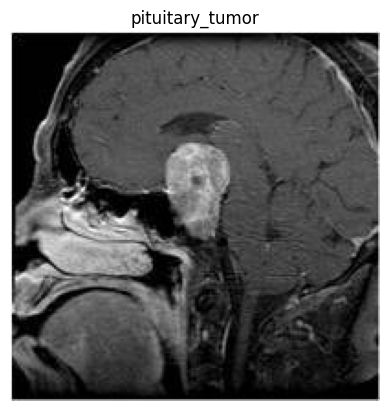

In [ ]:
# Importar librerias
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Elegimos una clase al azar
clase = np.random.choice(os.listdir("my_dataset/Testing"))

# Elegimos una imagen al azar de esa clase
archivo = np.random.choice(
    os.listdir(os.path.join("my_dataset/Testing", clase))
)

ruta = os.path.join("my_dataset/Testing", clase, archivo)

# Leemos la imagen
img = cv2.imread(ruta)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostramos la imagen
plt.imshow(img)
plt.title(clase)
plt.axis('off')
plt.show()

In [ ]:
# Almacenando una imagen aleatoria de test en mi BASE_FOLDER
cv2.imwrite(BASE_FOLDER + 'tumor.png', img)

False

# Inspección del dataset

Vamos a revisar el dataset antes de comenzar con el entrenamiento.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import glob
import os
import random
from PIL import Image
import shutil

DATA_DIR = "my_dataset"
training_files = glob.glob(os.path.join(DATA_DIR, 'Training', '*', '*.jpg'))
no_tumor_files = glob.glob(os.path.join(DATA_DIR, 'Training', 'no_tumor', '*.jpg'))
glioma_tumor = glob.glob(os.path.join(DATA_DIR, 'Training', 'glioma_tumor', '*.jpg'))
pituitary_tumor = glob.glob(os.path.join(DATA_DIR, 'Training', 'pituitary_tumor', '*.jpg'))
meningioma_tumor = glob.glob(os.path.join(DATA_DIR, 'Training', 'meningioma_tumor', '*.jpg'))

print(f'Imágenes totales en Training: {len(training_files)}')
print(f'Imágenes totales de no tumor: {len(no_tumor_files)}')
print(f'Imágenes totales de glioma tumor: {len(glioma_tumor)}')
print(f'Imágenes totales de pituitary tumor: {len(pituitary_tumor)}')
print(f'Imágenes totales de meningioma tumor: {len(meningioma_tumor)}')


Imágenes totales en Training: 2870
Imágenes totales de no tumor: 395
Imágenes totales de glioma tumor: 826
Imágenes totales de pituitary tumor: 827
Imágenes totales de meningioma tumor: 822


In [ ]:
# Revisamos el tamaño de las imgágenes
sizes = np.array([Image.open(f).size for f in training_files])
print(f'Tamaño mínimo: {sizes.min(axis=0)}')
print(f'Tamaño máximo: {sizes.max(axis=0)}')
print(f'Tamaño medio: {sizes.mean(axis=0)}')

Tamaño mínimo: [180 198]
Tamaño máximo: [1375 1446]
Tamaño medio: [480.10940767 481.41637631]


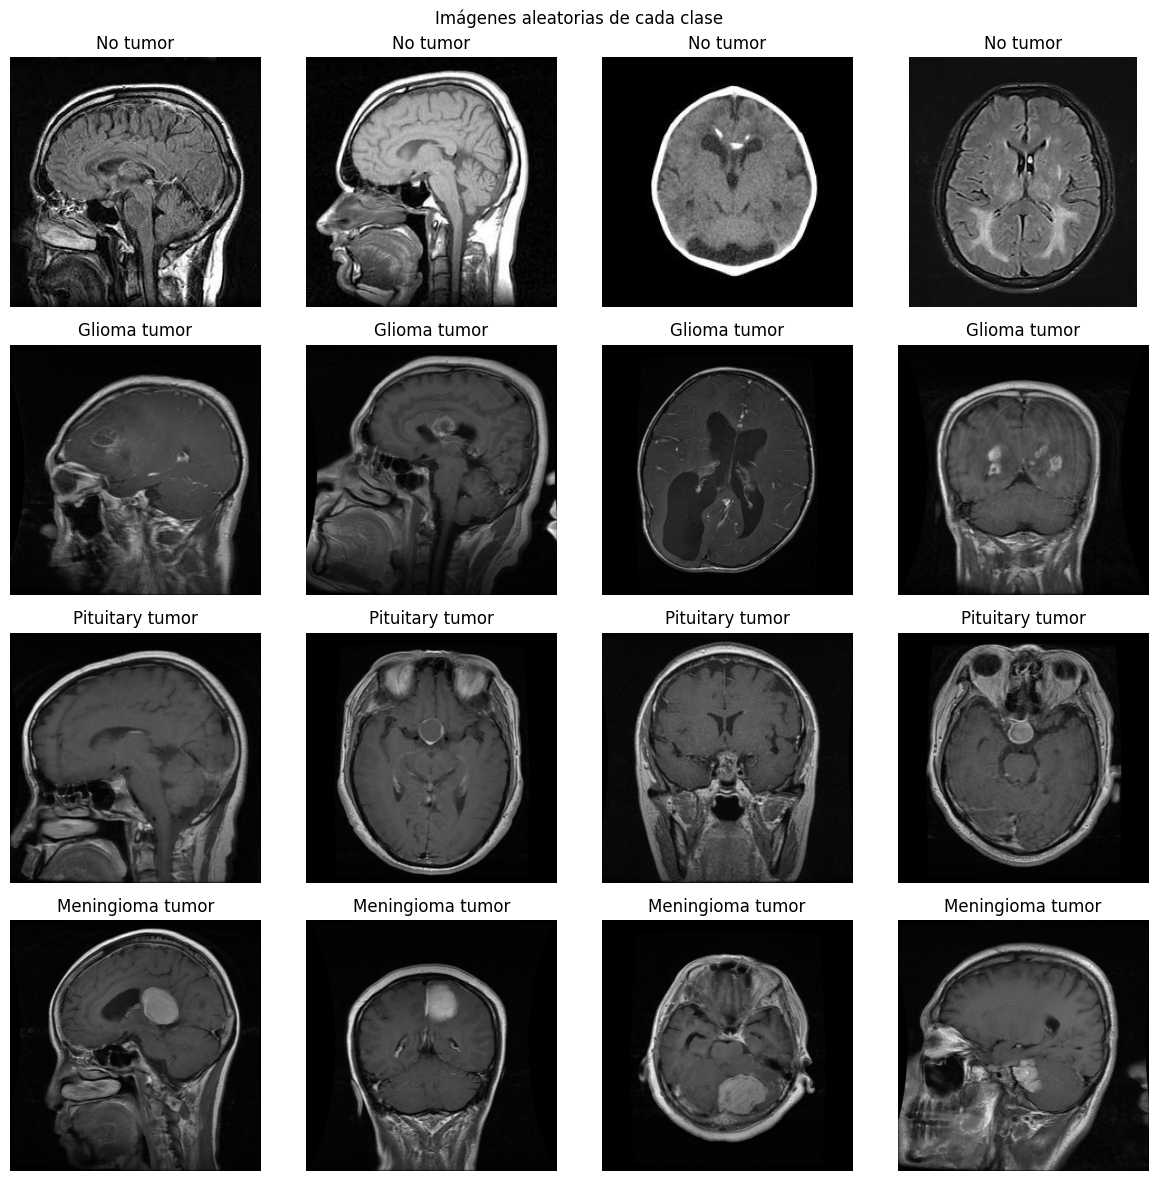

In [ ]:
# Vamos a ver imágenes de cada clase.

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, f in enumerate(random.sample(no_tumor_files, 4)):
    axes[0, i].imshow(Image.open(f))
    axes[0, i].axis('off')
    axes[0, i].set_title('No tumor')
for i, f in enumerate(random.sample(glioma_tumor, 4)):
    axes[1, i].imshow(Image.open(f))
    axes[1, i].axis('off')
    axes[1, i].set_title('Glioma tumor')
for i, f in enumerate(random.sample(pituitary_tumor, 4)):
    axes[2, i].imshow(Image.open(f))
    axes[2, i].axis('off')
    axes[2, i].set_title('Pituitary tumor')
for i, f in enumerate(random.sample(meningioma_tumor, 4)):
    axes[3, i].imshow(Image.open(f))
    axes[3, i].axis('off')
    axes[3, i].set_title('Meningioma tumor')

plt.suptitle('Imágenes aleatorias de cada clase')
plt.tight_layout()
plt.show()


Acondicionamiento


In [ ]:
WORKING_DIR = "data_split"
shutil.rmtree(WORKING_DIR, ignore_errors=True)
os.makedirs(f'{WORKING_DIR}/no_tumor_sep', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/glioma_tumor_sep', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/pituitary_tumor_sep', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/meningioma_tumor_sep', exist_ok=True)

N_por_clase = 1000
for f in no_tumor_files[:N_por_clase]:
    shutil.copy(f, f'{WORKING_DIR}/no_tumor_sep')
for f in glioma_tumor[:N_por_clase]:
    shutil.copy(f, f'{WORKING_DIR}/glioma_tumor_sep')
for f in pituitary_tumor[:N_por_clase]:
    shutil.copy(f, f'{WORKING_DIR}/pituitary_tumor_sep')
for f in meningioma_tumor[:N_por_clase]:
    shutil.copy(f, f'{WORKING_DIR}/meningioma_tumor_sep')

print(f'no tumor: {len(os.listdir(f"{WORKING_DIR}/no_tumor_sep"))}')
print(f'glioma tumor: {len(os.listdir(f"{WORKING_DIR}/glioma_tumor_sep"))}')
print(f'pituitary tumor: {len(os.listdir(f"{WORKING_DIR}/pituitary_tumor_sep"))}')
print(f'meningioma tumor: {len(os.listdir(f"{WORKING_DIR}/meningioma_tumor_sep"))}')


no tumor: 395
glioma tumor: 826
pituitary tumor: 827
meningioma tumor: 822


Split del dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

IMAGEN_SIZE = 160
BATCH_SIZE = 32
SEED = 42

training_dataset = tf.keras.utils.image_dataset_from_directory(
    WORKING_DIR,
    validation_split=0.2,
    subset='training',
    image_size=IMAGEN_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    WORKING_DIR,
    validation_split=0.2,
    subset='validation',
    image_size=IMAGEN_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical' # Added label_mode='categorical' here
    )

class_names = training_dataset.class_names
print(f'Clases: {class_names}')

AUTOTUNE = tf.data.AUTOTUNE
training_dataset = training_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.
Clases: ['glioma_tumor_sep', 'meningioma_tumor_sep', 'no_tumor_sep', 'pituitary_tumor_sep']


Data Augmentation

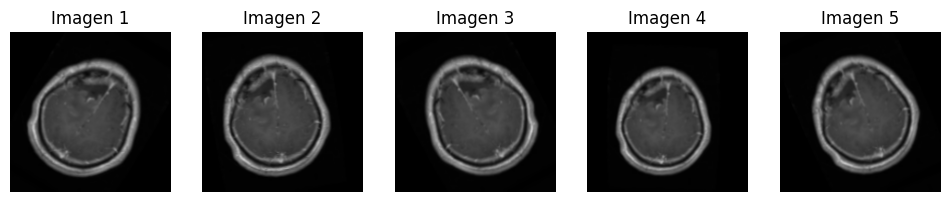

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
import matplotlib.pyplot as plt
import numpy as np

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
], name = 'data_augmentation')

# Se mria el efecto sobre una imagen
for imagenes, etiquetas in training_dataset.take(1):
    fig, axes = plt.subplots(1, 5, figsize=(12, 12))
    imagen = imagenes[0]
    axes[0]. imshow(imagen.numpy().astype('uint8'))
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    for i in range(5):
        augmented_image = data_augmentation(tf.expand_dims(imagen, 0),
                                            training=True)
        axes[i].imshow(np.clip(augmented_image[0].numpy(), 0, 255).astype('uint8'))
        axes[i].set_title(f'Imagen {i+1}')
        axes[i].axis('off')
    plt.show()

Ploteado del entrenamiento

In [ ]:
def ploteado_historial(history, title=''):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h['loss'], label='train')
    axes[0].plot(h['val_loss'], label='val')
    axes[0].set_title(f'Loss - {title}')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h['accuracy'], label='train')
    axes[1].plot(h['val_accuracy'], label='val')
    axes[1].set_title(f'Accuracy - {title}')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('acc')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"  best val_loss: {min(h['val_loss']):.4f}")
    print(f"  best val_acc:  {max(h['val_accuracy']):.4f}")

def mejores_metricas(hist):
    h = hist.history
    return {
        'best_val_acc': max(h['val_accuracy']),
        'best_val_loss': min(h['val_loss']),
        'final_train_acc': h['accuracy'][-1],
        'final_val_acc': h['val_accuracy'][-1],
    }

In [ ]:
def cnn_baseline():
  model = models.Sequential([
      layers.Input((IMAGEN_SIZE, IMAGEN_SIZE, 3)),
      layers.Rescaling(1./255),
      layers.Conv2D(32, 3, activation='relu', padding='same'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, activation='relu', padding='same'),
      layers.MaxPooling2D(),
      layers.Conv2D(128, 3, activation='relu', padding='same'),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(len(class_names), activation='softmax')
  ], name= 'cnn_baseline')

  model.compile(
      optimizer=optimizers.Adam(1e-3),
      loss='categorical_crossentropy', # Changed loss back to categorical_crossentropy
      metrics=['accuracy']
  )
  return model

baseline = cnn_baseline()
baseline.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,492 (25.36 MB)

 Trainable params: 6,647,492 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

EPOCHS_BASE = 15
t0 = time.time()
history_base = baseline.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_BASE,
    verbose=2
)

print(f'Tiempo de entrenamiento: {time.time()-t0:.1f}s')

Epoch 1/15
72/72 - 8s - 112ms/step - accuracy: 0.5967 - loss: 0.9718 - val_accuracy: 0.7387 - val_loss: 0.6470
Epoch 2/15
72/72 - 2s - 30ms/step - accuracy: 0.7822 - loss: 0.5480 - val_accuracy: 0.7840 - val_loss: 0.5188
Epoch 3/15
72/72 - 2s - 30ms/step - accuracy: 0.8676 - loss: 0.3339 - val_accuracy: 0.8293 - val_loss: 0.4346
Epoch 4/15
72/72 - 2s - 30ms/step - accuracy: 0.9299 - loss: 0.2106 - val_accuracy: 0.8275 - val_loss: 0.4236
Epoch 5/15
72/72 - 2s - 30ms/step - accuracy: 0.9338 - loss: 0.1592 - val_accuracy: 0.8955 - val_loss: 0.3431
Epoch 6/15
72/72 - 2s - 31ms/step - accuracy: 0.9699 - loss: 0.0740 - val_accuracy: 0.9007 - val_loss: 0.3725
Epoch 7/15
72/72 - 2s - 31ms/step - accuracy: 0.9839 - loss: 0.0517 - val_accuracy: 0.9059 - val_loss: 0.4014
Epoch 8/15
72/72 - 2s - 31ms/step - accuracy: 0.9965 - loss: 0.0145 - val_accuracy: 0.9024 - val_loss: 0.4859
Epoch 9/15
72/72 - 2s - 31ms/step - accuracy: 0.9991 - loss: 0.0069 - val_accuracy: 0.8902 - val_loss: 0.5146
Epoch 10/

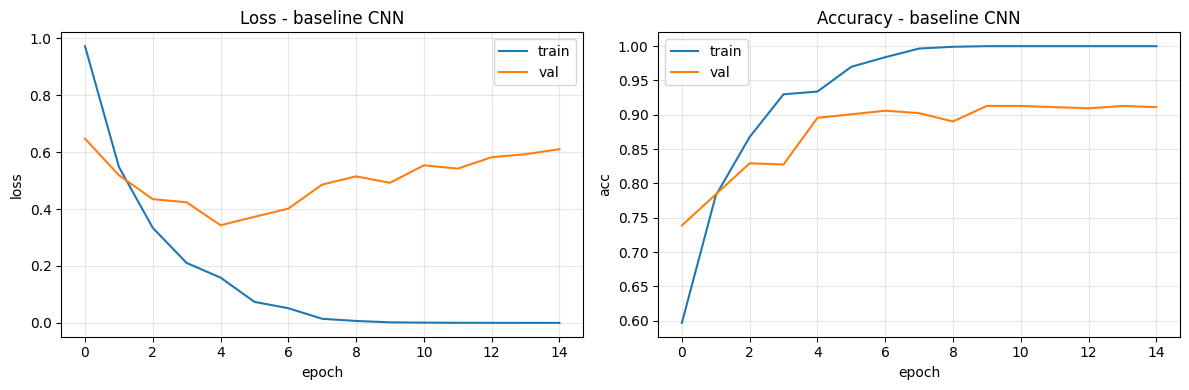

  best val_loss: 0.3431
  best val_acc:  0.9129


In [ ]:
ploteado_historial(history_base, 'baseline CNN')

Modelo mejorado

In [ ]:
def cnn_regularizado():
  l2 = regularizers.l2(0.001)
  input =layers.Input((IMAGEN_SIZE, IMAGEN_SIZE, 3))
  x = data_augmentation(input)
  x = layers.Rescaling(1./255)(x)
  # Bloque 1
  x = layers.Conv2D(32, 3, activation='relu', padding='same', kernel_regularizer=l2)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.MaxPooling2D()(x)
  # Bloque 2
  x = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_regularizer=l2)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.MaxPooling2D()(x)
  # Bloque 3
  x = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=l2)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.MaxPooling2D()(x)
  # Cabezal
  x =layers.GlobalAveragePooling2D()(x)
  x = layers.Dropout(0.4)(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.3)(x)
  output = layers.Dense(len(class_names), activation='softmax')(x) # Changed to len(class_names) units and softmax activation
  model = models.Model(inputs=input, outputs=output, name='regularized_cnn')
  model.compile(optimizer=optimizers.Adam(1e-3),
                loss='categorical_crossentropy', # Changed loss to categorical_crossentropy
                metrics=['accuracy'])
  return model

regularizado = cnn_regularizado()
regularizado.summary()

Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cb_reg = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

EPOCHS_REG = 25
t0 = time.time()
history_reg = regularizado.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_REG,
    verbose=2,
    callbacks=cb_reg
)

print(f'Tiempo entrenamiento: {time.time()-t0:.1f}s')


Epoch 1/25
72/72 - 13s - 187ms/step - accuracy: 0.4882 - loss: 1.2988 - val_accuracy: 0.3397 - val_loss: 1.4881 - learning_rate: 0.0010
Epoch 2/25
72/72 - 5s - 69ms/step - accuracy: 0.5906 - loss: 1.0818 - val_accuracy: 0.2700 - val_loss: 1.4847 - learning_rate: 0.0010
Epoch 3/25
72/72 - 5s - 68ms/step - accuracy: 0.6498 - loss: 0.9529 - val_accuracy: 0.2683 - val_loss: 1.4759 - learning_rate: 0.0010
Epoch 4/25
72/72 - 5s - 67ms/step - accuracy: 0.6524 - loss: 0.9187 - val_accuracy: 0.2753 - val_loss: 1.4407 - learning_rate: 0.0010
Epoch 5/25
72/72 - 5s - 71ms/step - accuracy: 0.6886 - loss: 0.8606 - val_accuracy: 0.3258 - val_loss: 1.4452 - learning_rate: 0.0010
Epoch 6/25
72/72 - 5s - 68ms/step - accuracy: 0.7204 - loss: 0.7907 - val_accuracy: 0.4094 - val_loss: 1.3475 - learning_rate: 0.0010
Epoch 7/25
72/72 - 5s - 68ms/step - accuracy: 0.7252 - loss: 0.7580 - val_accuracy: 0.3641 - val_loss: 1.2887 - learning_rate: 0.0010
Epoch 8/25
72/72 - 5s - 71ms/step - accuracy: 0.7496 - loss:

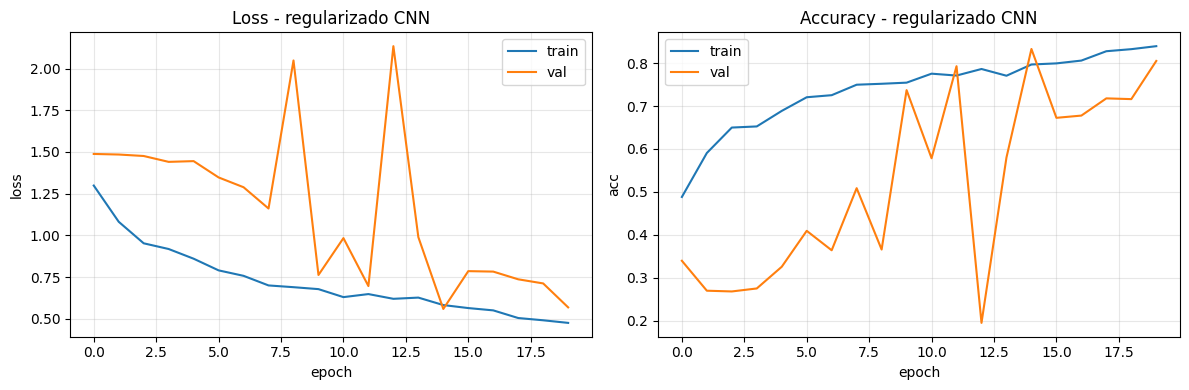

  best val_loss: 0.5595
  best val_acc:  0.8328


In [ ]:
ploteado_historial(history_reg, 'regularizado CNN')

In [ ]:
import pandas as pd
# Comparativa interna estrategia 1
df_s1 = pd.DataFrame({
    'cnn_baseline': mejores_metricas(history_base),
    'cnn_regularized': mejores_metricas(history_reg),
}).T
df_s1.round(4)

,best_val_acc,best_val_loss,final_train_acc,final_val_acc
cnn_baseline,0.9129,0.3431,1.0000,0.9111
cnn_regularized,0.8328,0.5595,0.8393,0.8049


## Ejemplo de generación de documento PDF a partir del Colab Notebook (fichero ".ipynb")

In [ ]:
# Ejecutando los siguientes comandos en la última celda del Colab Notebook se convierte de ".ipynb" a PDF
# En caso de querer ocultar la salida de una celda puesto que no tenga relevancia se debe insertar
# el comando %%capture al inicio de la misma. Véase la celda que contiene !ls test en este Notebook.

In [ ]:
name_IPYNB_file = '07MIAR_Proyecto_Programacion.ipynb'
get_ipython().system(
        "apt update >> /dev/null && apt install texlive-xetex texlive-fonts-recommended texlive-generic-recommended >> /dev/null"
    )
get_ipython().system(
            "jupyter nbconvert --output-dir='$BASE_FOLDER' '$BASE_FOLDER''$name_IPYNB_file' --to pdf"
        )